![clothing_classification](figures/clothing_classification.png)

### Project Goal

As a data scientist for the new e-commerce retailer, Fashion Forward, I have been tasked with developing a robust garment classifier. The primary objective is to build a deep learning model that accurately categorizes product images into 10 distinct classes (e.g., T-shirt, Trouser, Coat). This automated system is critical for streamlining the product listing process, enhancing customer search experience, and improving inventory management.

### My Approach

To solve this problem, I will follow a structured data science workflow:

1.  **Data Exploration and Preparation**: I will start by performing an Exploratory Data Analysis (EDA) on the FashionMNIST dataset to understand its characteristics and prepare it for modeling. This includes creating a validation set to properly evaluate model performance during training.
2.  **Baseline Model**: I will define and train a simple Convolutional Neural Network (CNN) as a baseline to establish an initial performance benchmark.
3.  **Iterative Improvement**: I will systematically improve upon the baseline by conducting experiments, such as increasing training duration and deepening the network architecture. I will track training and validation metrics to diagnose model behavior.
4.  **Final Evaluation**: I will select the best-performing model and conduct a final, comprehensive evaluation on the held-out test set. This will include generating a confusion matrix to analyze class-specific performance and identify common misclassifications.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns

# Import functions from our refactored scripts
from src.data_loader import get_data_loaders
from src.model import BaselineCNN, DeeperCNN
from src.train import train_and_validate
from src.evaluate import evaluate_model
from src.visualization import show_random_samples, plot_history

# Set the style for the plots
sns.set_theme(style="whitegrid")

In [6]:
import random
import numpy as np

# For reproducibility
def set_seed(seed):
    """Set seed for reproducibility."""
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  # if you are using multi-GPU.
    np.random.seed(seed)  # Numpy module.
    random.seed(seed)  # Python random module.
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

set_seed(42)

In [7]:
# Load the data using the refactored function
train_loader, val_loader, test_loader, classes = get_data_loaders(batch_size=64)
num_classes = len(classes)

# To get the full dataset for EDA, we can access it from one of the loaders
full_train_data = train_loader.dataset.dataset

print(f"Classes: {classes}")
print(f"Number of classes: {num_classes}")

Number of training examples: 48000
Number of validation examples: 12000
Number of testing examples: 10000
Classes: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
Number of classes: 10


In [13]:
# Get the length of each dataset
train_size = len(train_loader.dataset)
val_size = len(val_loader.dataset)
test_size = len(test_loader.dataset)

print(f"Size of the training set: {train_size} samples")
print(f"Size of the validation set: {val_size} samples")
print(f"Size of the test set: {test_size} samples")

Size of the training set: 48000 samples
Size of the validation set: 12000 samples
Size of the test set: 10000 samples


### Exploratory Data Analysis

Before building the model, I will perform an Exploratory Data Analysis (EDA) to understand the dataset's characteristics. This involves checking the class distribution to ensure it is balanced and visualizing sample images to get a qualitative sense of the classification task.

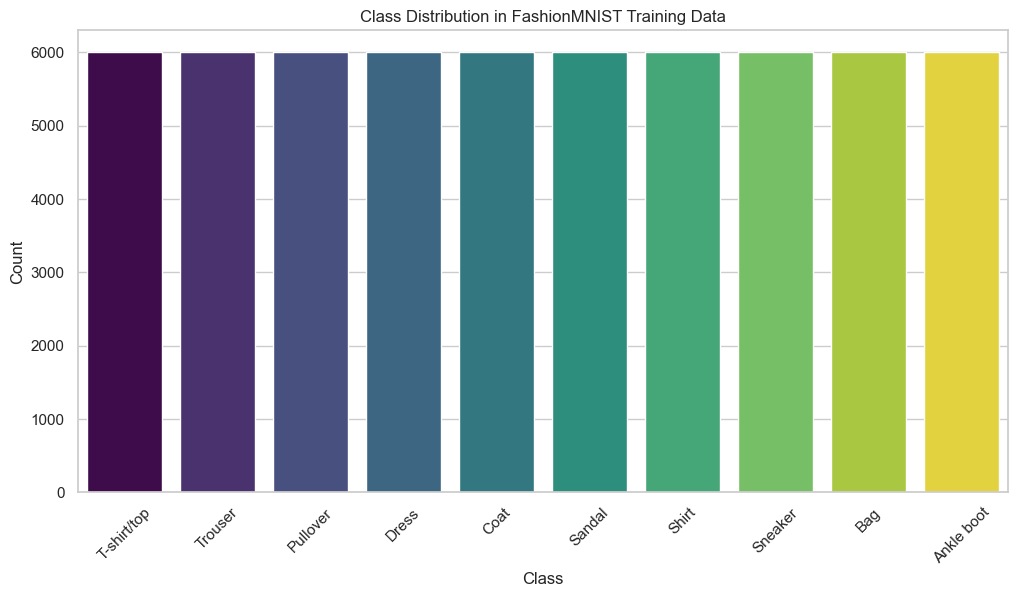

In [8]:
# Visualize class distribution
plt.figure(figsize=(12, 6))
# We use the targets from the full training dataset to get the overall distribution
sns.countplot(x=full_train_data.targets, hue=full_train_data.targets, palette="viridis", legend=False)
plt.title('Class Distribution in FashionMNIST Training Data')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(ticks=range(num_classes), labels=classes, rotation=45)
plt.savefig('./figures/class_distribution.png')
plt.show()

Image size for Training Set: 28x28 pixels


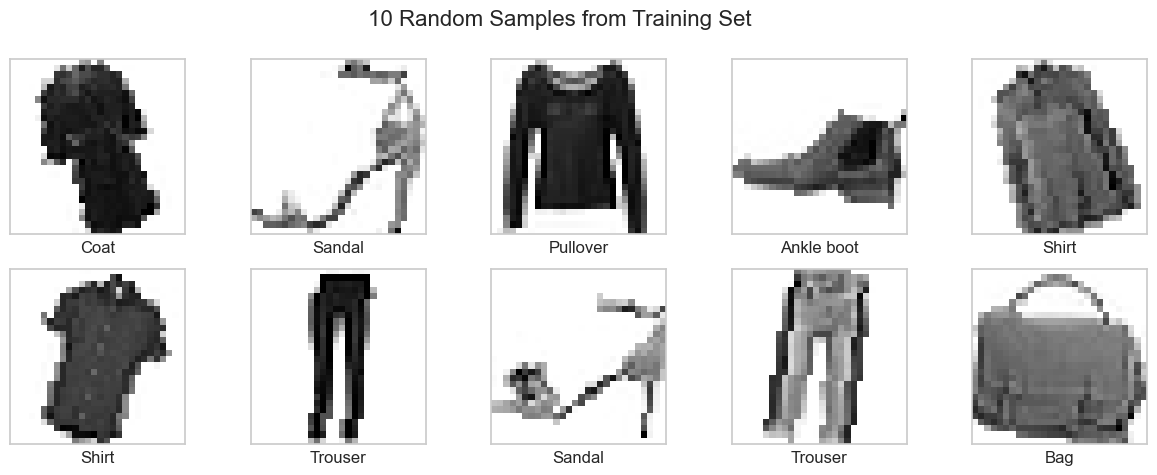

Image size for Validation Set: 28x28 pixels


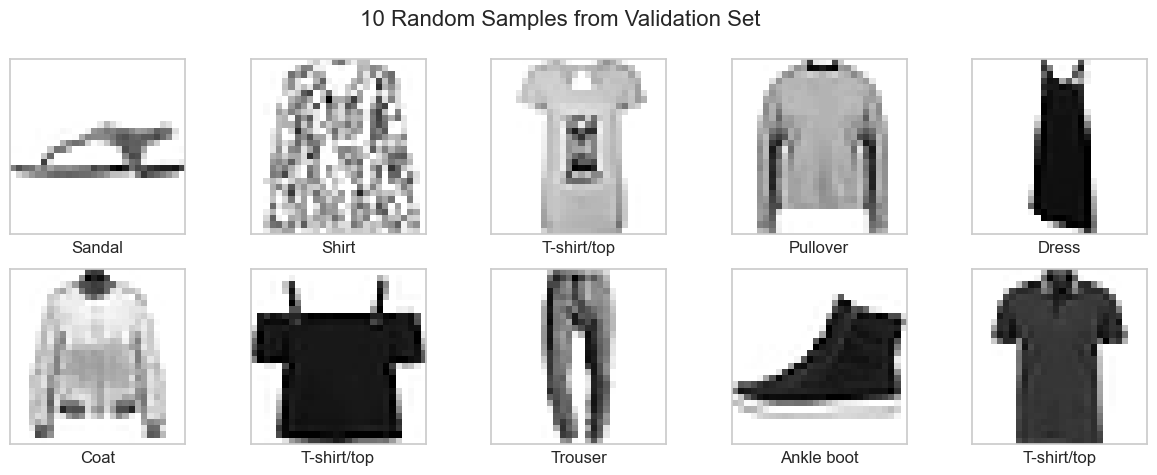

Image size for Test Set: 28x28 pixels


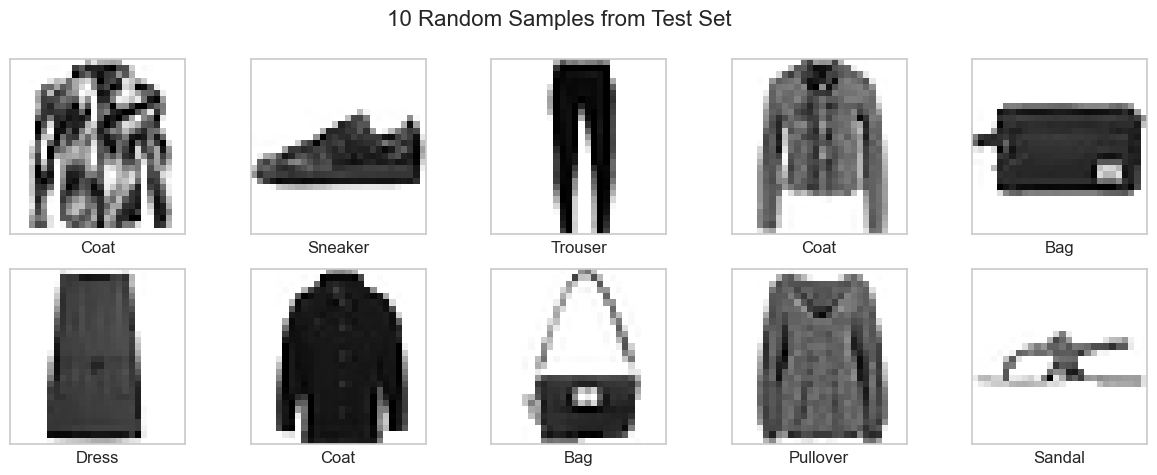

In [14]:
# Display samples from each loader
show_random_samples(train_loader, 'Training Set', classes)
show_random_samples(val_loader, 'Validation Set', classes)
show_random_samples(test_loader, 'Test Set', classes)

### Experiment 1: Baseline CNN Model

I will begin by training the simple, single-layer `BaselineCNN` for a limited number of epochs. This will provide a performance baseline and allow me to verify that the training pipeline is working correctly. I selected `Adam` as the optimizer and `CrossEntropyLoss` as the criterion, which are standard and effective choices for this type of multi-class classification problem.

Training Baseline CNN...
Epoch 1/5 | Train Loss: 0.6539, Train Acc: 0.7687 | Val Loss: 0.4945, Val Acc: 0.8307
Epoch 1/5 | Train Loss: 0.6539, Train Acc: 0.7687 | Val Loss: 0.4945, Val Acc: 0.8307
Epoch 2/5 | Train Loss: 0.4987, Train Acc: 0.8219 | Val Loss: 0.4710, Val Acc: 0.8336
Epoch 2/5 | Train Loss: 0.4987, Train Acc: 0.8219 | Val Loss: 0.4710, Val Acc: 0.8336
Epoch 3/5 | Train Loss: 0.4571, Train Acc: 0.8376 | Val Loss: 0.4237, Val Acc: 0.8518
Epoch 3/5 | Train Loss: 0.4571, Train Acc: 0.8376 | Val Loss: 0.4237, Val Acc: 0.8518
Epoch 4/5 | Train Loss: 0.4369, Train Acc: 0.8464 | Val Loss: 0.3981, Val Acc: 0.8619
Epoch 4/5 | Train Loss: 0.4369, Train Acc: 0.8464 | Val Loss: 0.3981, Val Acc: 0.8619
Epoch 5/5 | Train Loss: 0.4212, Train Acc: 0.8517 | Val Loss: 0.3995, Val Acc: 0.8622
Plot saved to ./figures/experiment_1_history.png
Epoch 5/5 | Train Loss: 0.4212, Train Acc: 0.8517 | Val Loss: 0.3995, Val Acc: 0.8622
Plot saved to ./figures/experiment_1_history.png


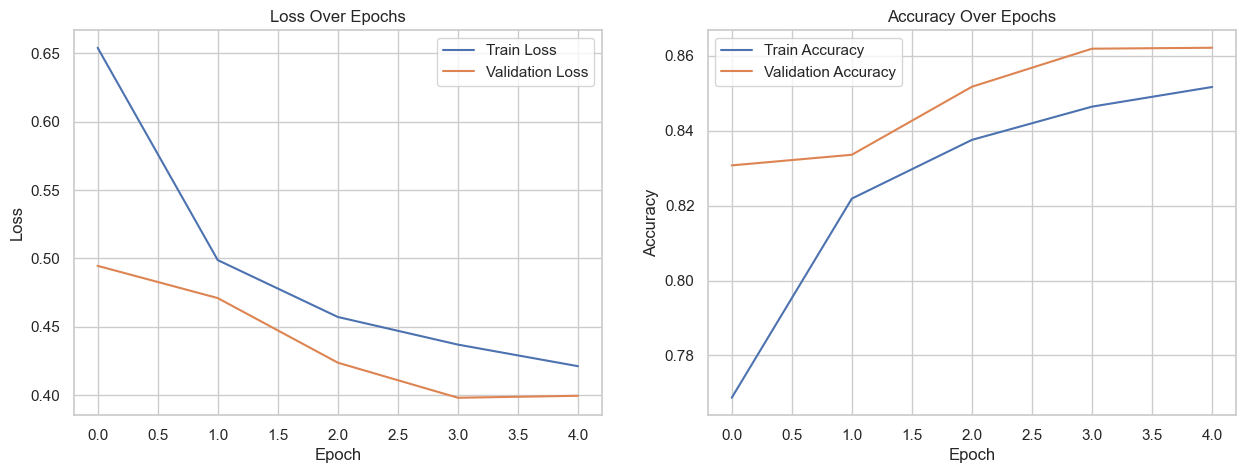

In [10]:
# Instantiate the baseline model, optimizer, and loss function
baseline_model = BaselineCNN(num_classes=num_classes)
optimizer = optim.Adam(baseline_model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

# Train for 5 epochs
print("Training Baseline CNN...")
baseline_history = train_and_validate(
    model=baseline_model,
    optimizer=optimizer,
    criterion=criterion,
    num_epochs=5,
    train_loader=train_loader,
    val_loader=val_loader,
    num_classes=num_classes
)

# Plot the results
plot_history(baseline_history, save_path='./figures/experiment_1_history.png')

### Experiment 2: Training for More Epochs

The baseline model's validation accuracy was still trending upward after 5 epochs, suggesting it was under-trained. For my next experiment, I will continue training the same `BaselineCNN` architecture but for a total of 15 epochs to see if performance improves with more training time.

Training Baseline CNN for 30 epochs...
Epoch 1/30 | Train Loss: 0.6323, Train Acc: 0.7770 | Val Loss: 0.4789, Val Acc: 0.8355
Epoch 1/30 | Train Loss: 0.6323, Train Acc: 0.7770 | Val Loss: 0.4789, Val Acc: 0.8355
Epoch 2/30 | Train Loss: 0.4751, Train Acc: 0.8327 | Val Loss: 0.4356, Val Acc: 0.8519
Epoch 2/30 | Train Loss: 0.4751, Train Acc: 0.8327 | Val Loss: 0.4356, Val Acc: 0.8519
Epoch 3/30 | Train Loss: 0.4419, Train Acc: 0.8440 | Val Loss: 0.4203, Val Acc: 0.8551
Epoch 3/30 | Train Loss: 0.4419, Train Acc: 0.8440 | Val Loss: 0.4203, Val Acc: 0.8551
Epoch 4/30 | Train Loss: 0.4225, Train Acc: 0.8515 | Val Loss: 0.4128, Val Acc: 0.8594
Epoch 4/30 | Train Loss: 0.4225, Train Acc: 0.8515 | Val Loss: 0.4128, Val Acc: 0.8594
Epoch 5/30 | Train Loss: 0.4105, Train Acc: 0.8554 | Val Loss: 0.3865, Val Acc: 0.8692
Epoch 5/30 | Train Loss: 0.4105, Train Acc: 0.8554 | Val Loss: 0.3865, Val Acc: 0.8692
Epoch 6/30 | Train Loss: 0.4016, Train Acc: 0.8586 | Val Loss: 0.3701, Val Acc: 0.8725
Epoc

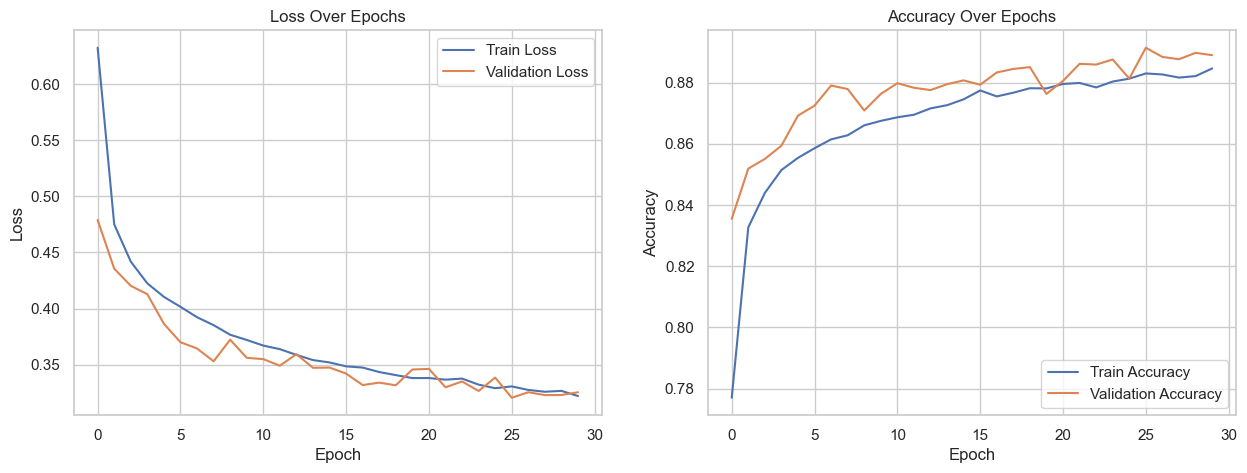

In [12]:
# Instantiate a new baseline model to train for longer
long_train_model = BaselineCNN(num_classes=num_classes)
optimizer = optim.Adam(long_train_model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

# Train for 30 epochs
print("Training Baseline CNN for 30 epochs...")
long_train_history = train_and_validate(
    model=long_train_model,
    optimizer=optimizer,
    criterion=criterion,
    num_epochs=30,
    train_loader=train_loader,
    val_loader=val_loader,
    num_classes=num_classes
)

# Plot the results
plot_history(long_train_history, save_path='./figures/experiment_2_history.png')

### Experiment 3: Using a Deeper Network

Analysis of Experiment 2 reveals that while extending training to 30 epochs initially boosted validation accuracy, the performance gains diminished and plateaued around epoch 15. This suggests that the `BaselineCNN` has reached its learning capacity and is now likely limited by its simple architecture rather than the training duration.

To overcome this limitation, Experiment 3 will introduce a more complex model: `DeeperCNN`. By adding a second convolutional and pooling layer, this network is designed to capture more intricate features from the images. We will train it for 15 epochs, as this was the point where the baseline model's learning saturated, providing a sufficient duration to evaluate the new architecture's potential without excessive training time.

Training Deeper CNN...
Epoch 1/15 | Train Loss: 0.7030, Train Acc: 0.7380 | Val Loss: 0.4315, Val Acc: 0.8419
Epoch 2/15 | Train Loss: 0.4584, Train Acc: 0.8331 | Val Loss: 0.3544, Val Acc: 0.8703
Epoch 3/15 | Train Loss: 0.3992, Train Acc: 0.8571 | Val Loss: 0.3281, Val Acc: 0.8798
Epoch 4/15 | Train Loss: 0.3630, Train Acc: 0.8690 | Val Loss: 0.3162, Val Acc: 0.8862
Epoch 5/15 | Train Loss: 0.3392, Train Acc: 0.8757 | Val Loss: 0.3003, Val Acc: 0.8888
Epoch 6/15 | Train Loss: 0.3163, Train Acc: 0.8862 | Val Loss: 0.2827, Val Acc: 0.8987
Epoch 7/15 | Train Loss: 0.3014, Train Acc: 0.8904 | Val Loss: 0.2611, Val Acc: 0.9033
Epoch 8/15 | Train Loss: 0.2873, Train Acc: 0.8962 | Val Loss: 0.2622, Val Acc: 0.9051
Epoch 9/15 | Train Loss: 0.2744, Train Acc: 0.8994 | Val Loss: 0.2493, Val Acc: 0.9080
Epoch 10/15 | Train Loss: 0.2664, Train Acc: 0.9025 | Val Loss: 0.2685, Val Acc: 0.9027
Epoch 11/15 | Train Loss: 0.2566, Train Acc: 0.9066 | Val Loss: 0.2548, Val Acc: 0.9057
Epoch 12/15 | Trai

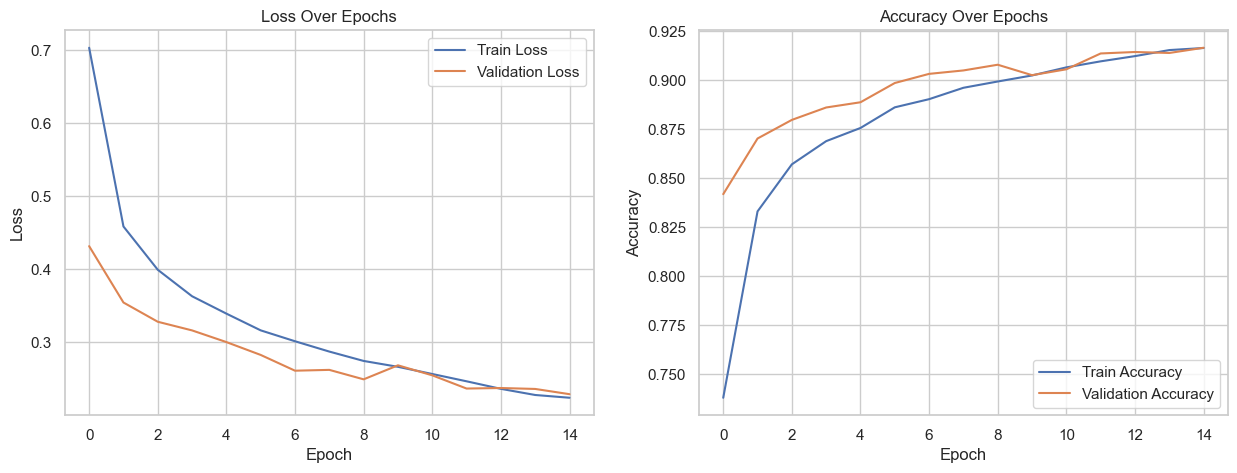

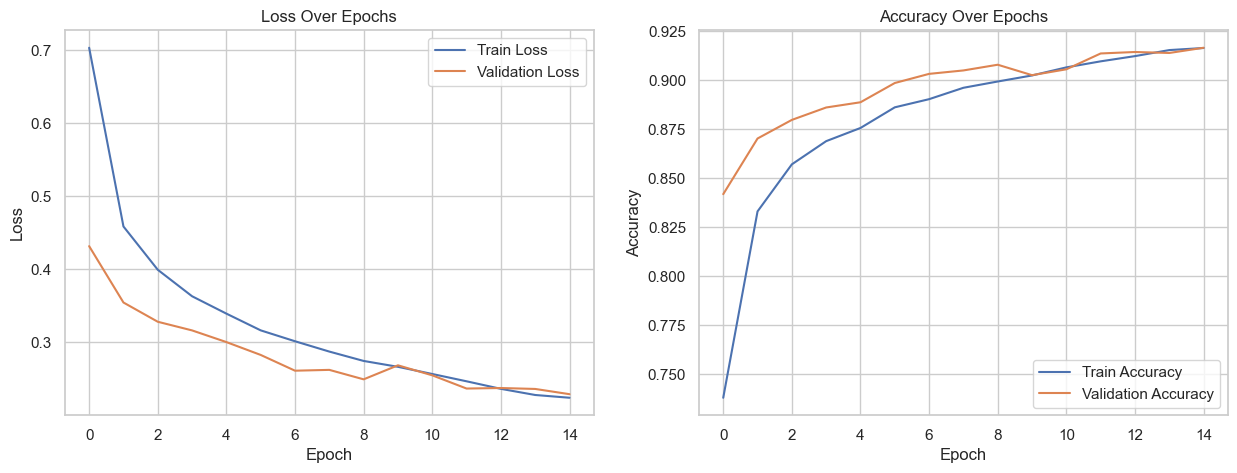

In [ ]:
# Instantiate the deeper model
deeper_model = DeeperCNN(num_classes=num_classes)
optimizer = optim.Adam(deeper_model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

# Train for 15 epochs
print("Training Deeper CNN...")
deeper_history = train_and_validate(
    model=deeper_model,
    optimizer=optimizer,
    criterion=criterion,
    num_epochs=15,
    train_loader=train_loader,
    val_loader=val_loader,
    num_classes=num_classes
)

# Plot and save the results
plot_history(deeper_history, save_path='./figures/experiment_3_history.png')
# # Save the training history plot
# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
# ax1.plot(deeper_history['train_loss'], label='Train Loss')
# ax1.plot(deeper_history['val_loss'], label='Validation Loss')
# ax1.set_title('Loss Over Epochs')
# ax1.set_xlabel('Epoch')
# ax1.set_ylabel('Loss')
# ax1.legend()
# ax2.plot(deeper_history['train_acc'], label='Train Accuracy')
# ax2.plot(deeper_history['val_acc'], label='Validation Accuracy')
# ax2.set_title('Accuracy Over Epochs')
# ax2.set_xlabel('Epoch')
# ax2.set_ylabel('Accuracy')
# ax2.legend()
# plt.savefig('./figures/training_history.png')
# plt.show()

### Final Model Evaluation

The `DeeperCNN` trained for 15 epochs achieved the highest and most stable validation accuracy. I have selected this as the final model. Now, I will perform a definitive evaluation on the held-out test set, which the model has not seen before. This will provide an unbiased assessment of its real-world performance.

The evaluation will include:
-   Overall test accuracy.
-   Per-class precision and recall to understand its strengths and weaknesses.
-   A confusion matrix to visualize misclassifications.

# Evaluate the best model on the test set


Evaluating final model on the test set...
Overall Test Accuracy: 0.9083

Per-Class Precision and Recall:
T-shirt/top : Precision=0.8623, Recall=0.8520
Trouser     : Precision=0.9909, Recall=0.9850
Pullover    : Precision=0.8229, Recall=0.8690
Dress       : Precision=0.9149, Recall=0.9030
Coat        : Precision=0.8296, Recall=0.8620
Sandal      : Precision=0.9820, Recall=0.9800
Shirt       : Precision=0.7604, Recall=0.7110
Sneaker     : Precision=0.9622, Recall=0.9660
Bag         : Precision=0.9869, Recall=0.9820
Ankle boot  : Precision=0.9691, Recall=0.9730


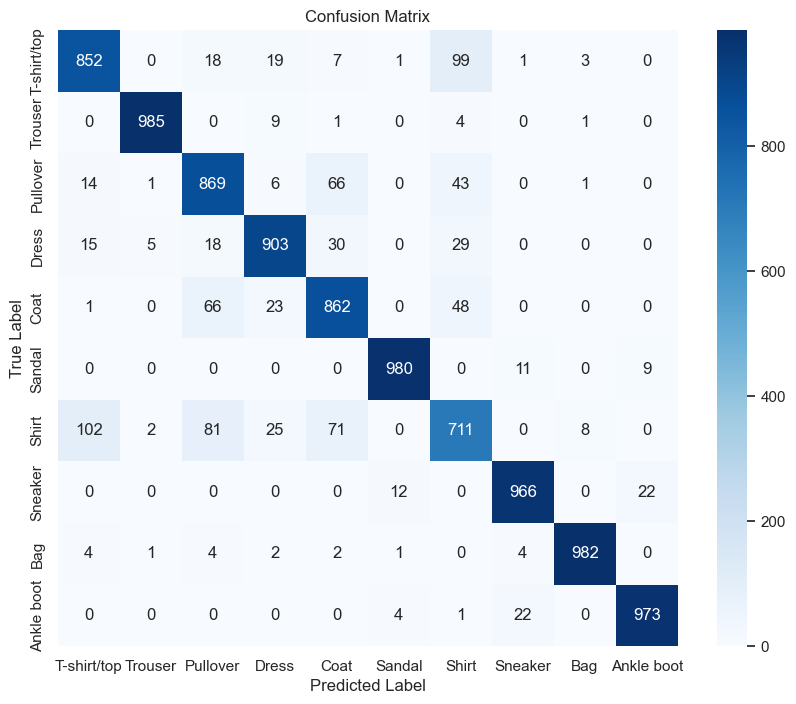

In [9]:
from sklearn.metrics import confusion_matrix

print("Evaluating final model on the test set...")
accuracy, precision, recall, all_labels, all_preds = evaluate_model(deeper_model, test_loader, classes)

# Save the confusion matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.savefig('./figures/confusion_matrix.png')
plt.show()

In [10]:
# Save the model state dictionary
model_save_path = "fashion_mnist_cnn.pth"
torch.save(deeper_model.state_dict(), model_save_path)
print(f"Model saved to {model_save_path}")

Model saved to fashion_mnist_cnn.pth


### Save the Final Model

To make the model usable for future inference without retraining, I will save its learned parameters (the `state_dict`) to a file. This is a crucial step for deploying the model into a production environment.